In [7]:
import pandas as pd
from pathlib import Path
import yaml
import matplotlib.pyplot as plt

In [8]:
with open("config.yaml", "r") as f:
    config = yaml.safe_load(f)

# Analyzing data from Games endpoint

In [9]:
clean_games_fp = Path(config['games_folder'] + config['games_clean_fp'])

games_df = pd.read_json(clean_games_fp, orient='records')
games_df['updated_at'] = pd.to_datetime(games_df['updated_at'], unit='s')
games_df['first_release_date'] = pd.to_datetime(games_df['first_release_date'], unit='s')

print(f"Total number of games: {len(games_df)}")
games_df.head()

Total number of games: 19087


,id,name,rating,updated_at,first_release_date
0,215217,Tiny Rogues,84.044635,2026-05-06 02:57:00,2022-09-23
1,25358,Deus Ex: Game of the Year Edition,86.842060,2026-05-06 02:56:38,2001-05-08
2,266684,Contra: Operation Galuga,70.088532,2026-05-06 02:55:34,2024-03-12
3,36476,Hellpoint,71.339723,2026-05-06 02:55:15,2020-07-30
4,245390,Trine 5: A Clockwork Conspiracy,74.410522,2026-05-06 02:55:06,2023-08-31


<Axes: >

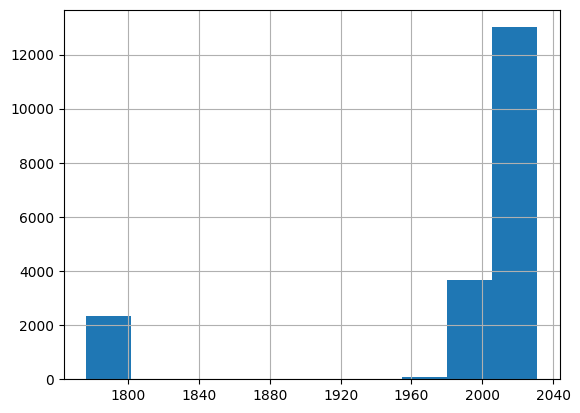

In [10]:
games_df['first_release_date'].hist()

### How many games of each mode

In [11]:
def get_feature_counts(feature, top_x = None):
    junctions_fp = Path(config['junctions_folder'] + config['junctions_fp_template'].format(field=feature))

    junctions_df = pd.read_json(junctions_fp, orient='records')

    lookup_fp = Path(config['lookups_folder'] + config['lookups_fp_template'].format(field=feature))

    lookup_df = pd.read_json(lookup_fp, orient='records')



    amounts = junctions_df.groupby(f'{feature}_id').count().rename(columns = {"game_id" : "count"}).reset_index()

    names_and_amounts = amounts.merge(lookup_df, how = 'inner', left_on = f'{feature}_id', right_on = 'id').get(['name', 'count']).sort_values(by = 'count', ascending = True)

    if top_x is not None:
        names_and_amounts = names_and_amounts.iloc[-top_x:]

    return plt.barh(names_and_amounts['name'], names_and_amounts['count'])

<BarContainer object of 6 artists>

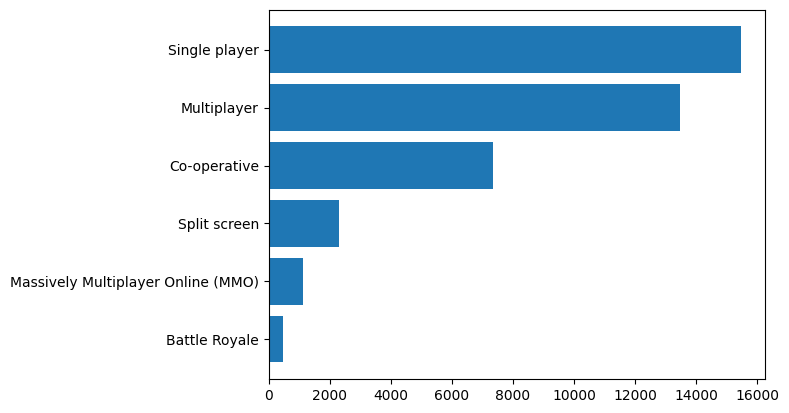

In [12]:
get_feature_counts('game_modes')

### How many games of each genre

<BarContainer object of 23 artists>

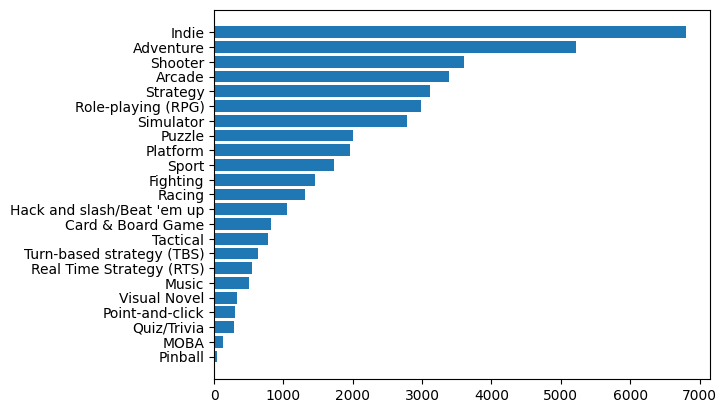

In [13]:
get_feature_counts('genres')

### How many games from each platform

<BarContainer object of 10 artists>

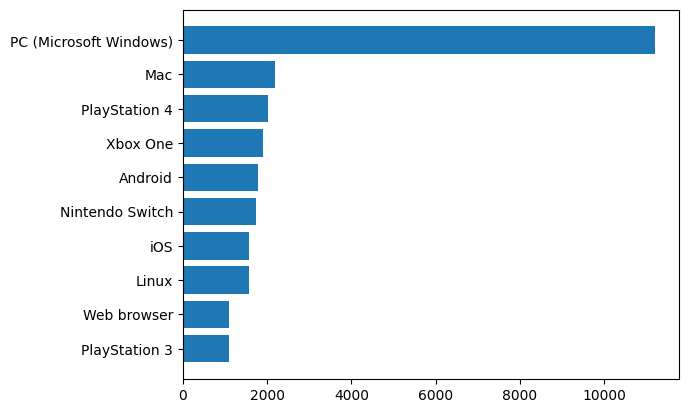

In [14]:
get_feature_counts('platforms', top_x = 10)

### Distribution of release dates

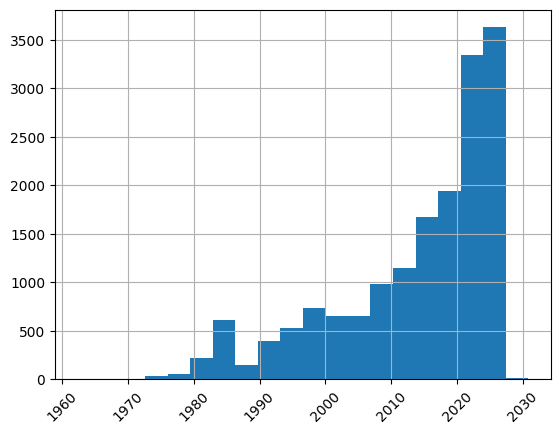

In [15]:
release_dates_without_outliers = games_df[games_df['first_release_date'] > pd.Timestamp('1950')]['first_release_date']

release_dates_without_outliers.hist(bins = 20)
plt.xticks(rotation=45)
plt.show()

# Analyzing data from multiplayer modes endpoint

In [16]:
clean_modes_fp = Path(config['multiplayer_modes_folder'] + config['multiplayer_modes_clean_fp'])

modes_df = pd.read_json(clean_modes_fp, orient='records')

print("Contains " + str(len(modes_df)) + " rows")
modes_df.head()

Contains 24044 rows


,id,game,dropin,campaigncoop,offlinecoop,offlinecoopmax,offlinemax,onlinecoop,onlinecoopmax,onlinemax,platform,splitscreen
0,9953,92273,False,False,False,0,2,False,0,0,22,False
1,1832,7153,True,True,True,2,0,False,0,0,12,False
2,7987,57887,False,False,True,2,2,False,0,0,49,False
3,7,46076,False,False,False,0,30,False,0,0,6,False
4,10207,31256,False,False,False,0,0,False,0,0,82,False


### Distributions of `offlinecoopmax` and `offlinemax`

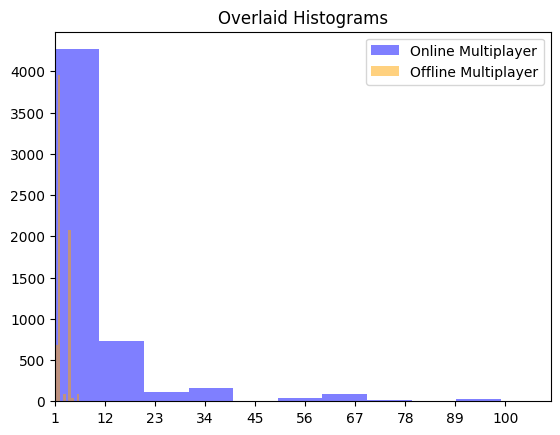

In [17]:
#Online max player data
onlinemax_column = modes_df['onlinemax'].sort_values(ascending = False)

online_threshold = onlinemax_column.quantile(.99)

onlinemax_column = onlinemax_column[(0 < onlinemax_column) & (onlinemax_column < online_threshold)]

#Offline max player data
offlinemax_column = modes_df['offlinemax'].sort_values(ascending = False)

offline_threshold = offlinemax_column.quantile(.99)

offlinemax_column = offlinemax_column[(0 < offlinemax_column) & (offlinemax_column < offline_threshold)]

plot_range = int(max(offline_threshold, online_threshold)+ 10)

plt.hist(onlinemax_column, alpha=0.5, label='Online Multiplayer', color='blue')
plt.hist(offlinemax_column, alpha=0.5, label='Offline Multiplayer', color='orange')
# Formatting
plt.legend(loc='upper right')
plt.title('Overlaid Histograms')
plt.xlim(1, plot_range)
plt.xticks(list(range(1,plot_range, int(plot_range / 10))))
plt.show()

Most offline games (expectedly) have very low player counts compared to online games.

In [18]:
games_df.columns

Index(['id', 'name', 'rating', 'updated_at', 'first_release_date'], dtype='str')

In [19]:
modes_df.columns

Index(['id', 'game', 'dropin', 'campaigncoop', 'offlinecoop', 'offlinecoopmax',
       'offlinemax', 'onlinecoop', 'onlinecoopmax', 'onlinemax', 'platform',
       'splitscreen'],
      dtype='str')